# 해상 리스크 대응형 공동 물류 운영·국내운송 연계 플랫폼

> **주관**: 한국해양수산개발원(KMI) × 위밋모빌리티 (Wemet Mobility)  
> **대회**: 2026학년도 1학기 기업문제해결 프로젝트 및 공모전  
> **기간**: 2026.04.29 ~ 2026.05.20

---

## 플랫폼 4단계 흐름

```
Step 1  화주 입력    화물종류·CBM·항로·납기·집화일
Step 2  MRI 산출    5차원 하이브리드 엔트로피 가중치 → 등급 판정 + 3개월 예측
Step 3  창고 추천   항만 인근 보세창고 5곳 추천 → 시나리오 A/B/C 비용 비교
Step 4  루티 JSON   출발지→창고 Phase 1 운송 지시서 생성
```


---
## 환경 설정 & 데이터 현황


In [1]:
import sys, os, asyncio

# Windows ProactorEventLoop + zmq 충돌 방지
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 자동 설정
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR     = ROOT / 'data'
PROJECT_ROOT = ROOT

# .env 로드 (API 키)
try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / '.env', override=False)
except ImportError:
    pass

print(f'ROOT: {ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'Python: {sys.version[:6]}')


ROOT: c:\Users\lwj88\OneDrive\바탕 화면\vs code\vs code\vs code
DATA_DIR: c:\Users\lwj88\OneDrive\바탕 화면\vs code\vs code\vs code\data
Python: 3.11.9


In [2]:
from src.real_data_fetcher import print_data_status
print_data_status(DATA_DIR)


  데이터 소스 현황

[API 키]
  ECOS (한국은행):       ✅ 설정됨  → 환율·두바이유 공식
     ※ 통계코드 시도순: 731Y003/0000001 → 731Y001/0000001 → 021Y151/USD
     ※ 유가 시도순:    902Y020/I61B → 902Y020/I61BCS
     ※ ECOS 실패 시 → frankfurter.app(환율) / FRED(유가) 자동 대체
  BPA (부산항만공사):    ✅ 설정됨  → 컨테이너 물동량 (연도별)
     ※ BPA API 실패 시 → data/busan_throughput.csv 수동 다운로드 필요
  KCCI (공공데이터포털): ❌ 미설정  → 운임지수
     ※ 발급: https://www.data.go.kr/data/15131881/openapi.do

[CSV 파일 (직접 다운로드)]
  KCCI:   ❌ 없음
         다운로드: https://www.forwarder.kr/freight/index/kcci
  부산항: ❌ 없음
         다운로드: https://www.busanpa.com/kor/Contents.do?mCode=MN1003

[자동 수집 (키 불필요, 매일 08:30 자동 갱신)]
  해사 뉴스 RSS: gCaptain / Splash247 / 한국해운신문
  USD/KRW 환율:  frankfurter.app (일별 실시간)
  Brent 유가:   Yahoo Finance BZ=F (일별 실시간)
              → FRED MCOILBRENTEU (Yahoo 실패 시 폴백)
              → EIA DEMO키 (최후 폴백)
  갱신 명령:    python scripts/auto_update.py --mode daily



---
## Step 1 — 화주 입력

아래 `SHIPPER_INPUT` 딕셔너리의 값을 수정하여 분석을 시작합니다.


In [3]:
# ══════════════════════════════════════════════════════
# Step 1. 화주 입력 — 아래 값을 수정하세요
# ══════════════════════════════════════════════════════
SHIPPER_INPUT = {
    'company':        '(주)한국무역',         # 화주 회사명
    'cargo_type':     '일반화물',              # 화물 종류
    'cbm':            15.0,                   # 화물 부피 (CBM)
    'route':          '아시아-유럽',           # 항로
    'origin_port':    '부산항(북항)',          # 출발 항만
    'dest_port':      'Rotterdam',            # 목적지 항만
    'pickup_date':    '2026-06-10',           # 집화일 (YYYY-MM-DD)
    'deadline_days':  21,                     # 납기 여유 (일)
    'origin_address': '경기도 화성시 마도면',  # 출발지 주소
    'region':         '경기남부',             # 출발 권역
    'freight_usd':    2200,                   # 현재 해상 운임 (USD/CBM)
}
print('화주 입력 완료:', SHIPPER_INPUT)


화주 입력 완료: {'company': '(주)한국무역', 'cargo_type': '일반화물', 'cbm': 15.0, 'route': '아시아-유럽', 'origin_port': '부산항(북항)', 'dest_port': 'Rotterdam', 'pickup_date': '2026-06-10', 'deadline_days': 21, 'origin_address': '경기도 화성시 마도면', 'region': '경기남부', 'freight_usd': 2200}


---
# Part 1 — 해상 리스크 지수(MRI) 산출

## 1-0. MRI란 무엇인가?

**MRI(Maritime Risk Index, 해상 리스크 지수)**는 현재 해운·항만 환경의 위험 수준을  
**0.0(안전) ~ 1.0(최고 위험)** 범위의 단일 지수로 표현하는 종합 리스크 지표입니다.

화주(수출입 화물 관리자)가 별도의 뉴스 모니터링 없이도  
"지금 배를 보내도 될까?"를 즉시 판단할 수 있도록 설계되었습니다.

---

## 1-1. MRI 5차원 구성

MRI는 서로 다른 성격의 **5개 차원(Dimension)**을 조합하여 산출합니다.

| 차원 | 이름 | 의미 | 데이터 소스 |
|------|------|------|------------|
| **G** | 지정학·항로 리스크 | 전쟁·분쟁·해적·항로 봉쇄 | GDELT BigQuery CSV (2015~) + Naver DataLab (2016~) |
| **D** | 운항 방해·부정 감성 | 기상 악화·선박 지연·항만 파업 | GDELT 부정 감성 비율 + Naver DataLab |
| **F** | 운임 변동 리스크 | 월간 운임지수 변동폭 | SCFI/CCFI Excel (2015~2022) + KCCI XLS (2022~현재) |
| **V** | 물동량 리스크 | 부산항 물동량 연간 감소율 | BPA 월별 물동량 XLS (2015~현재) + LSTM 예측 |
| **P** | 항만·통상 리스크 | 관세 분쟁·수출 규제·항만 혼잡 | GDELT 제재 이벤트 + Naver DataLab |

---

## 1-2. 각 차원 상세 계산 방법

### G — 지정학·항로 리스크

```
G = GDELT_G × 0.80 + Naver_G × 0.20      (2016년 이후)
G = GDELT_G                                (2015년: Naver DataLab 서비스 전)
```

- **GDELT_G**: 예멘·이란·러시아·우크라이나 등 해운 핫스팟 국가 관련 분쟁 이벤트 건수  
  → GDELT CAMEO 이벤트 코드 11~19(물리적 분쟁·강압)  
  → 95 퍼센타일 기준 [0,1] 정규화
- **Naver_G**: "홍해", "수에즈", "호르무즈", "지정학", "해상분쟁" 검색량 지수  
  → 한국 사용자 반응 속도 포착 (GDELT 번역 오류 보완)
- **왜 80:20?** GDELT는 전 세계 이벤트를 구조적으로 집계하므로 정보량이 많음.  
  Naver는 한국 언론 반응을 보완하는 역할이므로 20% 비중만 부여.

### D — 운항 방해·부정 감성

```
D_gdelt = (Tone < -3인 해운 이벤트 수) / (전체 해운 이벤트 수)
D = D_gdelt × 0.80 + Naver_D × 0.20
```

- GDELT의 AvgTone 점수가 -3 미만인 이벤트를 "강한 부정"으로 분류
  (해운 뉴스 평균 Tone ≈ -2.0이므로 -3 미만은 위기 수준)
- Naver_D: "태풍", "기상악화", "선박지연", "결항", "해상안전" 검색량

### F — 운임 변동 리스크

```
freight_combined =
    2015-02 ~ 2022-10: SCFI × 0.70 + CCFI × 0.30
    2022-11 ~ 현재   : KCCI × 0.70 + SCFI × 0.30
F_raw = |월간 변화율|     (절댓값, [0,1] 클리핑)
```

- KCCI(한국해운거래소): 2022년 11월부터 제공. 한국 출발 항로 기준
- SCFI(상해컨테이너운임지수): 글로벌 기준 운임 지표
- CCFI(중국컨테이너운임지수): 아시아 발 운임 보완

### V — 물동량 리스크 (핵심 차원)

```
rolling_annual = 부산항 물동량 12개월 이동 합산
yoy_rolling    = rolling_annual의 전년 동기 대비 변화율
V = max(0, min(-yoy_rolling / 0.10, 1.0))
```

- **왜 12개월 롤링 YoY?** 단순 월간 비교(MoM)는 음력설(1~2월 감소) 같은 계절성에 오염.  
  12개월 누적합으로 계산하면 계절 패턴이 상쇄되어 순수한 연간 수요 변화만 포착.
- **포화점**: 연간 물동량이 10% 이상 감소하면 V=1.0 (최대 위험)
- **2026년 4~5월 공백 처리**: BPA 공식 발표 전이므로 LSTM으로 예측하여 채움
  (2-layer LSTM, 64 유닛, 80 에포크)

### P — 항만·통상 리스크

```
P_gdelt = GDELT 제재·통상 이벤트 건수 (CAMEO 코드 1211, 1221, 1231, 1241)
P = P_gdelt × 0.80 + Naver_P × 0.20
```

- Naver_P: "항만파업", "관세", "무역분쟁", "수출규제", "항만혼잡" 검색량

---

## 1-3. 가중치 산출: IQR 로버스트 엔트로피 + 등분 하이브리드

### 왜 고정 가중치가 아닌가?

MRI 가중치를 "전문가 의견"으로 고정하면 특정 전문가의 편향이 들어갑니다.  
대신 **2015~현재까지의 실제 데이터**가 각 차원에 얼마나 많은 정보를 담고 있는지  
수학적으로 측정하여 가중치를 자동 산출합니다.

### Step 1 — IQR Tukey 울타리 이상치 제거

COVID-19 같은 극단적 이상치가 가중치를 독점하는 것을 방지합니다.

```python
lower = Q1 - 1.5 × IQR  (음수는 0으로 처리)
upper = Q3 + 1.5 × IQR
→ 이 범위 밖 값은 경계값으로 클리핑
```

### Step 2 — Shannon 엔트로피 가중치

```
p_ij  = 정규화값_i / 전체 합
e_j   = -(1/ln(n)) × Σ p_ij × ln(p_ij)     (Shannon 엔트로피)
d_j   = 1 - e_j                              (분산도: 변화가 클수록 높음)
w_j   = d_j / Σ d_j                         (합=1로 정규화)
```

→ 기간 내 변동이 **많은** 차원 = 정보량 많음 = **높은 가중치**

### Step 3 — 등분 가중치(0.2×5)와 평균 (하이브리드 설계)

> **[핵심 설계 근거 — 다중공선성 보정]**
>
> G·D·F·V·P 5차원은 서로 **독립적이지 않습니다**.
> 예를 들어 전쟁이 발생하면:
> - G(지정학) 상승
> - D(부정 뉴스) 상승
> - F(운임) 상승
>
> 이 세 차원이 동시에 오르므로 **다중공선성(Multicollinearity)**이 발생합니다.  
> 순수 엔트로피는 이 구조를 인식하지 못하고 COVID 충격이 집중된 V(물동량)에  
> 64%의 가중치를 부여하는 편향이 생깁니다.
>
> 이를 해소하기 위해 엔트로피 가중치와 등분 가중치(0.2씩)를 **단순 평균**하여  
> 엔트로피의 정보량 신호는 살리되, 특정 차원의 독점을 방지합니다.
>
> 참고: Wang & Lee (2020), "Hybrid Entropy-Equal Weight MCDM for Supply Chain Risk"

```python
hybrid_weights = (entropy_weights + equal_weights) / 2
                                # equal_weights = [0.2, 0.2, 0.2, 0.2, 0.2]
```

---

## 1-4. 최종 가중치 및 MRI 공식

2015-02 ~ 2026-05 실데이터 136개월 기준:

| 차원 | 엔트로피 | 등분 | **하이브리드 (최종)** |
|------|---------|------|---------------------|
| G (지정학) | 0.064 | 0.200 | **0.132** |
| D (부정감성) | 0.065 | 0.200 | **0.132** |
| F (운임) | 0.166 | 0.200 | **0.183** |
| V (물동량) | 0.675 | 0.200 | **0.437** |
| P (통상) | 0.030 | 0.200 | **0.115** |

```
MRI = 0.132·G + 0.132·D + 0.183·F + 0.437·V + 0.115·P
```

---

## 1-5. MRI 등급 기준

등급 임계값은 **러프한 직관값(0.3/0.5/0.7) 대신** 실데이터 136개월의  
**분위수 분석 + Jenks 자연 구간**으로 결정했습니다.

| 등급 | 임계값 | 통계적 근거 | 역사 검증 |
|------|--------|-----------|----------|
| 🟢 정상 | ~ 0.33 미만 | 75th 퍼센타일 | 일반 해상 운영 |
| 🟡 주의 | 0.33 ~ 0.43 | 75~91th | 홍해 위기 정점(0.39) 포함 |
| 🟠 경계 | 0.43 ~ 0.55 | 91~95th | 복합 위기 구간 |
| 🔴 위험 | 0.55 이상 | 상위 5% | 수에즈 에버기븐(0.65), COVID(0.69) |

- **창고 추천**: MRI 등급에 관계없이 모든 플랫폼 이용 고객에게 제공됩니다.
- **시나리오 비교**: MRI 등급이 높을수록 외부 창고 활용의 절약 효과가 커집니다.

---

## 1-6. 데이터 소스 상세

| 데이터 | 소스 | 기간 | 비고 |
|--------|------|------|------|
| SCFI (상해컨테이너운임지수) | 상해항운교역소 (SSE) | 2015-01~2026-05 | 글로벌 컨테이너 운임 기준 |
| CCFI (중국컨테이너운임지수) | 중국항운거래소 | 2015-01~2026-05 | 아시아 발 운임 보완 |
| KCCI (한국컨테이너운임지수) | 한국해운거래소 (KSIS) | 2022-11~현재 | 한국 출발 항로 기준 |
| 부산항 월별 물동량 | 부산항만공사(BPA) XLS | 2015-01~2026-03 | 단위: 만 톤 R/T |
| GDELT 이벤트 | Google BigQuery (gdeltv2) | 2015-02~현재 | 해운 관련 국가 이벤트 |
| Naver DataLab | 네이버 오픈API | 2016-01~현재 | 한국어 검색 트렌드 |

**GDELT BigQuery 쿼리 조건:**
- 국가 필터: KOR, CHN, JPN, USA, SGP, MYS, THA, TWN, YEM, IRN, RUS, UKR
- 이벤트 코드: CAMEO 11~19 (분쟁·강압), 1211/1221 (제재)
- 부정 감성 기준: AvgTone < -3 (GDELT 표준 위기 기준)
- Naver DataLab 비중 20%: 한국어 뉴스 커버리지 보완 (GDELT 번역 오류 경감)

---


In [4]:
# ════════════════════════════════════════════════════
# Step 2. MRI 산출 — 실데이터 기반 역대 시계열
# ════════════════════════════════════════════════════
from src.historical_mri_builder import build_real_mri_series, print_weight_comparison

print('MRI 시계열 산출 중 (136개월, 2015-02 ~ 현재)...')
mri_history_df = build_real_mri_series(
    data_dir=DATA_DIR,
    project_root=PROJECT_ROOT,
)

# 현재 MRI 출력
latest = mri_history_df.iloc[-1]
print(f'\n현재 MRI ({latest["date"].strftime("%Y-%m")}): {latest["mri_entropy"]:.3f}')
print(f'현재 등급: {__import__("src.mri_engine", fromlist=["mri_grade"]).mri_grade(latest["mri_entropy"])[0]}')

print_weight_comparison(mri_history_df)


MRI 시계열 산출 중 (136개월, 2015-02 ~ 현재)...

현재 MRI (2026-05): 0.191
현재 등급: 🟢 정상

━━━ MRI 가중치 비교 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  차원                  엔트로피      등분       하이브리드  막대(하이브리드)
────────────────────────────────────────────────────────────────
  G (지정학)            0.064   0.200       0.132  ███
  D (부정감성)           0.065   0.200       0.132  ███
  F (운임)             0.166   0.200       0.183  █████
  V (물동량)            0.675   0.200       0.437  █████████████
  P (통상제재)           0.030   0.200       0.115  ███
────────────────────────────────────────────────────────────────
  [설계 근거] G·D·F·V·P는 독립적이지 않음 (다중공선성).
  순수 엔트로피 가중치와 등분 가중치(0.2)의 평균으로 균형을 확보함.

  데이터 소스: F:real(SCFI/CCFI/KCCI) | V:LSTM_filled | V:real(BPA-rollingYoY) | G,D,P:real(GDELT+Naver)


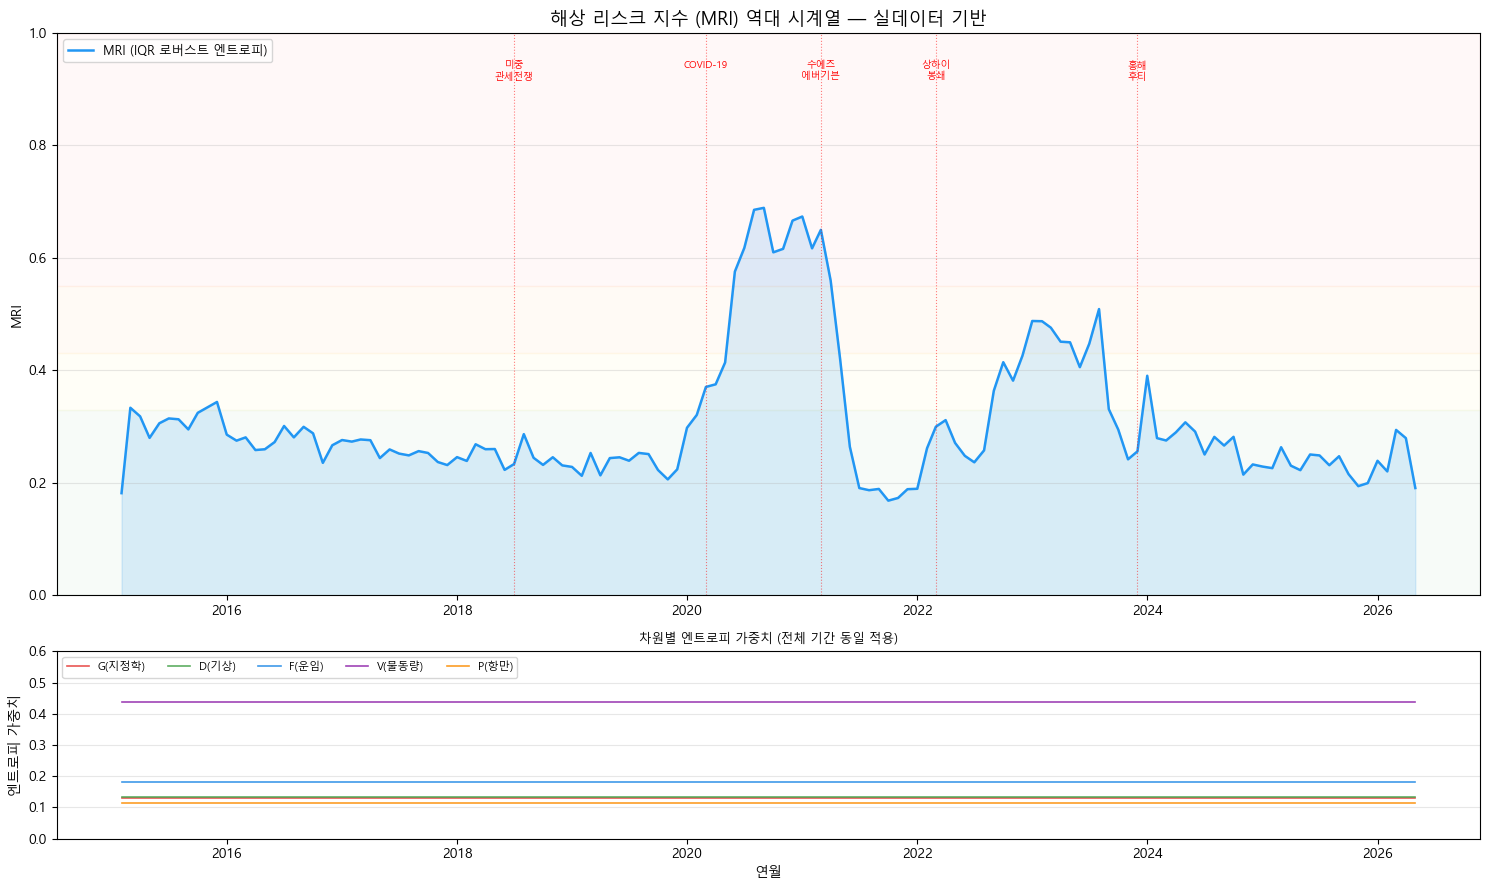

In [5]:
# 역대 MRI 시계열 차트 (2015-02 ~ 현재)
from src.historical_mri_builder import plot_real_mri
plot_real_mri(mri_history_df)


---
## 1-7. MRI 3개월 단기 예측

부산항 물동량 LSTM 예측과 과거 역사적 사례를 결합하여  
향후 3개월 MRI 추이를 예측하고, 상승·유지·하락 확률을 제공합니다.

| 예측 차원 | 방법 |
|---------|------|
| **F (운임)** | LSTM으로 freight_combined 3개월 예측 (1-layer LSTM, 32 유닛, 60 에포크) |
| **V (물동량)** | 과거 동월 평균 YoY 변화율 (계절성 반영) |
| **G, D, P** | 현재값 유지 + 시간 경과에 따른 감쇠 (1.0 → 0.90 → 0.82) |
| **확률 산출** | 현재 MRI ±0.10 범위 내 과거 사례에서 3개월 후 변화 분포 집계 |

**LSTM 구조**:
```
BPA 물동량 시계열 (136개월) → 2-layer LSTM(64) → FC → 다음 3개월 예측
시드 고정(42), 시간순 분할, 역정규화 후 V 차원 입력값으로 변환
```


C:\Users\lwj88\AppData\Local\Temp\ipykernel_21376\3130501947.py:51: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\lwj88\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


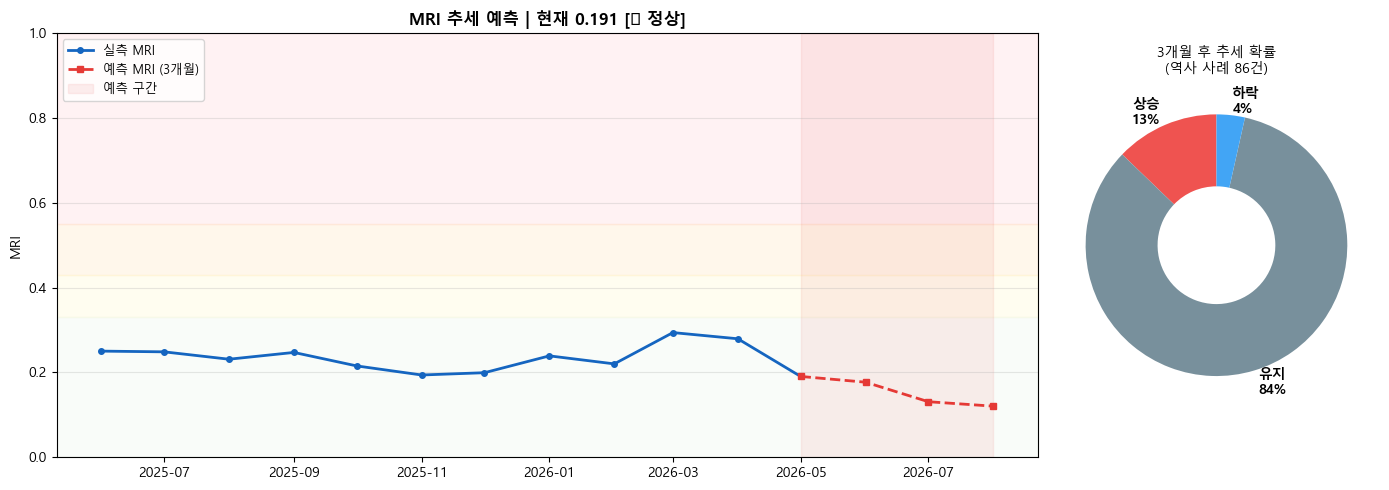


[근거] 현재 MRI 0.191 [🟢 정상] 기준 ±0.1 범위 역사 사례 86건 분석 (G·D·P 현재값 유지, F·V LSTM+계절 예측)

예측값:
  2026-06: MRI=0.177 [🟢 정상]  G=0.24 D=0.73 F=0.17 V=0.00 P=0.16
  2026-07: MRI=0.131 [🟢 정상]  G=0.21 D=0.65 F=0.00 V=0.00 P=0.14
  2026-08: MRI=0.120 [🟢 정상]  G=0.20 D=0.60 F=0.01 V=0.00 P=0.13


In [6]:
# MRI 3개월 추세 예측 + 확률
from src.historical_mri_builder import predict_mri_trend

trend = predict_mri_trend(
    mri_df=mri_history_df,
    data_dir=DATA_DIR,
    project_root=PROJECT_ROOT,
    forecast_months=3,
)

fdf   = trend['forecast_df']
p_up  = trend['prob_up']
p_st  = trend['prob_stay']
p_dn  = trend['prob_down']
n_his = trend['n_historical']
cur   = trend['current_mri']
grade = trend['current_grade']

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                                gridspec_kw={'width_ratios': [3, 1]})

hist_tail = mri_history_df.tail(12)
ax1.plot(hist_tail['date'], hist_tail['mri_entropy'],
         color='#1565C0', linewidth=2, marker='o', markersize=4, label='실측 MRI')
ax1.plot([hist_tail['date'].iloc[-1]] + list(fdf['date']),
         [cur] + list(fdf['mri_forecast']),
         color='#E53935', linewidth=2, linestyle='--',
         marker='s', markersize=5, label='예측 MRI (3개월)')

for lo, hi, col in [(0.55,1.0,'#FFCDD2'),(0.43,0.55,'#FFE0B2'),
                    (0.33,0.43,'#FFF9C4'),(0.0,0.33,'#E8F5E9')]:
    ax1.axhspan(lo, hi, alpha=0.25, color=col)

ax1.axvspan(hist_tail['date'].iloc[-1], fdf['date'].iloc[-1],
            alpha=0.08, color='#E53935', label='예측 구간')
ax1.set_ylim(0, 1)
ax1.set_ylabel('MRI')
ax1.set_title(f'MRI 추세 예측 | 현재 {cur:.3f} [{grade}]', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

labels = [f'상승\n{p_up:.0%}', f'유지\n{p_st:.0%}', f'하락\n{p_dn:.0%}']
sizes  = [p_up, p_st, p_dn]
colors = ['#EF5350', '#78909C', '#42A5F5']
ax2.pie(sizes, labels=labels, colors=colors, startangle=90,
        wedgeprops={'width': 0.55},
        textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title(f'3개월 후 추세 확률\n(역사 사례 {n_his}건)', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\n[근거] {trend["basis"]}')
print('\n예측값:')
from src.mri_engine import mri_grade
for _, r in fdf.iterrows():
    g2, _ = mri_grade(r['mri_forecast'])
    print(f"  {r['date'].strftime('%Y-%m')}: MRI={r['mri_forecast']:.3f} [{g2}]  "
          f"G={r['G']:.2f} D={r['D']:.2f} F={r['F']:.2f} V={r['V']:.2f} P={r['P']:.2f}")


In [7]:
# 실시간 해사 뉴스 피드 (최근 7일)
from src.real_data_fetcher import get_maritime_news_feed
from IPython.display import display, HTML

news = get_maritime_news_feed(top_n=10, days_back=7)

if not news:
    print('최근 7일 내 해사 리스크 관련 뉴스 없음 (RSS 연결 확인 필요)')
else:
    DIM_COLOR = {'G': '#EF5350', 'D': '#42A5F5', 'F': '#FF9800', 'P': '#AB47BC'}
    DIM_LABEL = {'G': 'G 지정학', 'D': 'D 운항방해', 'F': 'F 운임', 'P': 'P 통상'}

    rows = ['<table style="width:100%;border-collapse:collapse;font-size:13px">']
    rows.append('<tr style="background:#1565C0;color:white">')
    for h in ['발행일', '언론사', '제목', 'MRI 차원', '주요 키워드']:
        rows.append(f'<th style="padding:8px">{h}</th>')
    rows.append('</tr>')

    for i, art in enumerate(news):
        bg = '#F5F5F5' if i % 2 == 0 else '#FFFFFF'
        tags_html = ' '.join(
            f'<span style="background:{DIM_COLOR.get(t,"#888")};color:white;'
            f'padding:2px 6px;border-radius:3px;font-size:11px">'
            f'{DIM_LABEL.get(t,t)}</span>' for t in art['dim_tags'])
        kw_html = ', '.join(f'<code style="font-size:11px">{k}</code>' for k in art['keywords'])
        title_html = (
            f'<a href="{art["url"]}" target="_blank" style="color:#1565C0">{art["title"][:80]}</a>'
            if art['url'] else art['title'][:80])
        rows.append(f'<tr style="background:{bg}">')
        rows.append(f'<td style="padding:7px;text-align:center">{art["pub_date"]}</td>')
        rows.append(f'<td style="padding:7px;text-align:center">{art["source"]}</td>')
        rows.append(f'<td style="padding:7px">{title_html}</td>')
        rows.append(f'<td style="padding:7px;text-align:center">{tags_html}</td>')
        rows.append(f'<td style="padding:7px">{kw_html}</td>')
        rows.append('</tr>')

    rows.append('</table>')
    display(HTML(''.join(rows)))
    print(f'\n총 {len(news)}건 (최근 7일)')


발행일,언론사,제목,MRI 차원,주요 키워드
2026-05-15,gCaptain,UAE Will Double Oil Export Capacity Bypassing Hormuz by 2027,F 운임 G 지정학,"hormuz, strait, capacity"
2026-05-15,gCaptain,"China Wants Strait of Hormuz Open Free of Curbs, USTR Greer Tells Bloomberg News",G 지정학,"iran, hormuz"
2026-05-15,한국해운신문,"황종우 장관, 청해부대 48진 격려",G 지정학,위협
2026-05-15,한국해운신문,"선원노련, 청해부대에 위문금 전달",G 지정학,긴장
2026-05-15,한국해운신문,"해운·항만 5개 공기업, 사이버 안전 '맞손'",F 운임 G 지정학,"위협, 부족"
2026-05-15,한국해운신문,"트레드링스, AI 활용 선사 스케줄 예측 모델 출시",D 운항방해,기상
2026-05-15,한국해운신문,"KSS해운, 1분기 영업이익 27% 감소",F 운임,급등
2026-05-15,한국해운신문,상반기 군산·장항항 항만안전협의체 개최,P 통상,노조
2026-05-15,한국해운신문,"선원노련, 어기구 농해수위원장과 간담회",P 통상,노조
2026-05-14,gCaptain,Trump Says China Offered Help on Iran,G 지정학,"war, iran"



총 10건 (최근 7일)


---
# Part 2 — 과거 유사사례 분석

## 2-0. 설계 철학

MRI 수치 하나로 "홍해 시나리오"처럼 라벨을 붙이면 오류가 발생합니다.  
(예: MRI 0.39가 지정학 위기일 수도, 기상 악화일 수도 있음)

대신 **과거 유사 사례를 제시**하여 화주가 스스로 판단하도록 지원합니다.  
플랫폼은 "이런 상황이었을 때 평균 이렇게 됐어요"라는 참고 정보만 제공합니다.

## 2-1. 유사도 점수 산출 방식

```python
score = |현재 MRI - 과거 이벤트 MRI 피크| + range_penalty + category_penalty
# range_penalty  = 0.20  (현재 MRI가 해당 사건의 MRI 범위 밖일 때)
# category_penalty = 0.15  (NLP 분류 카테고리가 불일치할 때)
# 낮을수록 유사
```

## 2-2. 과거 이벤트 데이터베이스 (7건)

| 이벤트 | 기간 | 평균 지연 | 운임 상승 | 출처 |
|--------|------|---------|---------|------|
| 수에즈 에버기븐 | 2021-03 (6일) | 18일 | +34% | Port Economics, Project44 |
| 홍해 후티 공격 | 2023-12~ | 12일 | +141% | World Bank, UNCTAD 2024 |
| 미중 관세전쟁 | 2019-05 (90일) | 4일 | +9% | WTO 2019 |
| COVID-19 | 2020-03 (540일) | 21일 | +400% | UNCTAD 2021 |
| 태풍 힌남노 | 2022-09 (5일) | 7일 | +6% | BPA 2022 |
| 상하이 봉쇄 | 2022-04 (65일) | 14일 | +18% | S&P Global 2022 |
| ILWU 파업 위기 | 2023-06 (30일) | 8일 | +12% | Journal of Commerce 2023 |

> ⚠️ **참고 정보 안내**: 위 수치는 과거 사례의 평균값이며, 현재 상황은 다를 수 있습니다.  
> 실제 운송 결정은 포워더와 직접 상담하실 것을 권장합니다.


In [8]:
# 현재 MRI와 뉴스 키워드 기반 유사사례 매칭
from src.historical_matcher import find_similar_events, format_customer_message
from src.nlp_classifier import classify_news_df
from src.mri_engine import mri_grade

current_mri = float(mri_history_df.iloc[-1]['mri_entropy'])
grade_label, grade_color = mri_grade(current_mri)

# 뉴스 수집 & NLP 분류 (빠른 시연을 위해 RSS 30일치)
try:
    from src.real_data_fetcher import fetch_maritime_news
    news_df = fetch_maritime_news(days_back=30)
    if not news_df.empty:
        classified_df = classify_news_df(news_df)
        top_cat_counts = classified_df['category'].value_counts()
        top_cat = top_cat_counts.index[0] if not top_cat_counts.empty else '지정학분쟁'
        detected_cats = list(top_cat_counts.head(2).index)
    else:
        top_cat = '지정학분쟁'
        detected_cats = ['지정학분쟁']
except Exception:
    top_cat = '지정학분쟁'
    detected_cats = ['지정학분쟁']

similar_events = find_similar_events(current_mri, detected_cats, top_k=3)

print(f'현재 MRI: {current_mri:.3f} {grade_label}')
print(f'감지 카테고리: {detected_cats}')
print()
print(format_customer_message(current_mri, similar_events))


현재 MRI: 0.191 🟢 정상
감지 카테고리: ['지정학분쟁']

📊 현재 해상 리스크 지수 (MRI): 0.19

━━━ 과거 유사 사례 분석 ━━━
현재와 비슷한 수치가 기록됐던 과거 사례를 바탕으로
참고 정보를 제공합니다.

[1위] 미국 서부항만 ILWU 파업 협상 위기 (2023년) ── 🔵 MRI 수치 유사
   📌 원인: ILWU(국제항만창고노조)와 PMA 간 임금 협상 결렬 우려로 미국 서부 29개 항만 파업 임박. 화주들이 LA/롱비치 → 뉴욕/조지아 동부 항만으로 화물 전환 시도....
   ⏱  평균 지연: 8일
   💰 운임 상승: +12%
   🚢 영향 항로: 아시아-미주 서부
   🔚 해소 방식: 연방 조정위원회 중재로 잠정 합의, 전면 파업 회피.
   📖 출처: Journal of Commerce 2023 / USDA 공급망 보고서

[2위] 미중 관세 전쟁 1단계 (2019년) ── 🔵 MRI 수치 유사
   📌 원인: 미국이 2,000억 달러 규모 중국산 수입품에 관세 25% 부과. 수출 기업들의 선적 전·후 물동량 급변동, 선복 예측 불확실성 심화. 한국 수출기업도 간접 영향권 진입....
   ⏱  평균 지연: 4일
   💰 운임 상승: +9%
   🚢 영향 항로: 아시아-미주 서부, 한국-미주
   🔚 해소 방식: 2020년 1단계 무역합의 서명으로 일부 관세 완화.
   📖 출처: WTO 무역통계 2019 / KCCI 2019

[3위] 수에즈 운하 에버기븐 좌초 (2021년) ── ✅ 리스크 유형 일치
   📌 원인: 초대형 컨테이너선 에버기븐(Ever Given)이 수에즈 운하에 좌초, 전 세계 해상 교역량의 약 12%가 통과하는 핵심 항로를 6일간 완전 봉쇄. 약 400여 척의 선박이 대기하...
   ⏱  평균 지연: 18일
   💰 운임 상승: +34%
   🚢 영향 항로: 아시아-유럽, 아시아-지중해, 아시아-미주 동부
   🔚 해소 방식: 6일 만에 운하 통항 재개. 적체 선박 해소까지 약 3~4주 추가 

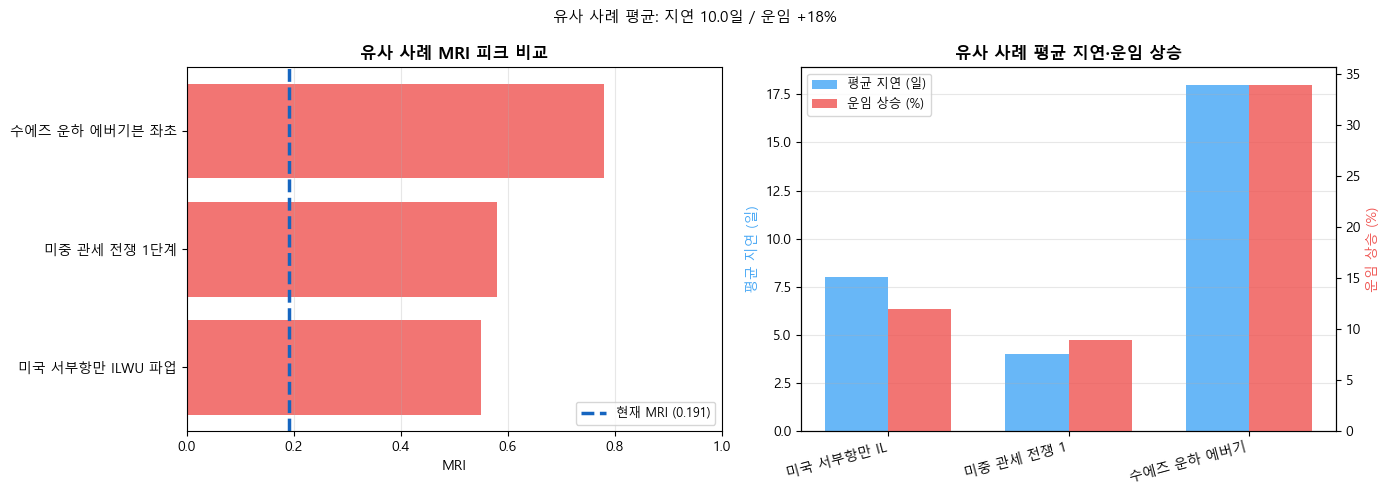

In [9]:
# 유사사례 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 과거 이벤트 MRI 분포 + 현재 MRI
event_names = [e['name'][:15] for e in similar_events]
event_mris  = [e['mri_peak'] for e in similar_events]
colors_bar  = ['#EF5350' if m >= 0.55 else '#FF9800' if m >= 0.43
               else '#FFC107' if m >= 0.33 else '#66BB6A'
               for m in event_mris]
bars = ax1.barh(event_names, event_mris, color=colors_bar, alpha=0.8)
ax1.axvline(current_mri, color='#1565C0', linewidth=2.5, linestyle='--',
            label=f'현재 MRI ({current_mri:.3f})')
ax1.set_xlim(0, 1)
ax1.set_xlabel('MRI')
ax1.set_title('유사 사례 MRI 피크 비교', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# 오른쪽: 평균 지연일 & 운임 상승 비교
x = np.arange(len(similar_events))
w = 0.35
delays   = [e['avg_delay_days']           for e in similar_events]
freights = [e['avg_freight_increase_pct'] for e in similar_events]

ax2b = ax2.twinx()
ax2.bar(x - w/2, delays,   w, color='#42A5F5', alpha=0.8, label='평균 지연 (일)')
ax2b.bar(x + w/2, freights, w, color='#EF5350', alpha=0.8, label='운임 상승 (%)')

ax2.set_xticks(x)
ax2.set_xticklabels([e['name'][:10] for e in similar_events], rotation=15, ha='right')
ax2.set_ylabel('평균 지연 (일)', color='#42A5F5')
ax2b.set_ylabel('운임 상승 (%)', color='#EF5350')
ax2.set_title('유사 사례 평균 지연·운임 상승', fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax2.grid(axis='y', alpha=0.3)

if similar_events:
    avg_d = sum(e['avg_delay_days'] for e in similar_events) / len(similar_events)
    avg_f = sum(e['avg_freight_increase_pct'] for e in similar_events) / len(similar_events)
    fig.suptitle(f'유사 사례 평균: 지연 {avg_d:.1f}일 / 운임 +{avg_f:.0f}%', fontsize=11)

plt.tight_layout()
plt.show()


---
# Part 3 — 항만 인근 창고·ODCY 추천 & 비용 시뮬레이션

## 3-0. 시나리오 정의

해상 리스크 발생 시 화주가 선택 가능한 세 가지 대응 시나리오를 비교합니다.

| 시나리오 | 내용 | 비용 특징 |
|---------|------|----------|
| **A — 무대응 (ODCY 이송)** | 화물을 CY에 반입 → 무료 장치기간(5일) 소진 → ODCY로 이송 | ODCY 10,000원/CBM/일 |
| **B — 무대응 (ODCY 만석)** | A와 동일 시작 → ODCY 자리 없어 CY에 계속 장치 | CY 초과장치료 30,000원/CBM/일 (최고가) |
| **C — 플랫폼 사전 탐지** ★ | MRI 이상 탐지 → 출발지에서 직접 보세창고 이송 | 보세창고 4,000원/CBM/일 (최저가) |

> **단가 근거** (2024년 부산항 주변 실제 문의 기준)
> - ODCY 보관료: **10,000원/CBM/일**
> - 외부 보세창고: **4,000원/CBM/일**
> - CY 초과장치료(Demurrage): **30,000원/CBM/일** (선사·부두 운영사마다 상이)
> - CY 무료 장치기간: 기본 **5일** (부두 반입 후, 선사별 차이 있음)

## 3-1. 창고 추천 방식

1. NLIC 국가물류통합정보센터 DB (439개, 정부 공인) 우선 탐색
2. 고객 목적지(항만 CY) 좌표 기준 Haversine 직선거리 계산
3. 화물 유형(일반/냉장/위험물) 필터 적용 후 **거리 오름차순 5곳** 추천
4. 화주가 직접 전화 문의 후 실제 가격 입력 → 총 예상 비용 자동 계산

> ⚠️ 현재 창고들과 공식 파트너십·계약은 없으며, 시뮬레이션 목적으로 가격을 제시합니다.  
> 실제 운영 시 창고별 개별 계약 및 가격 협상이 필요합니다.


In [10]:
# Step 3. 거리 기반 창고 5곳 추천
from src.odcy_recommender import (
    CargoType, PORT_COORDINATES, recommend_nearest_five, calc_total_with_user_price
)
from IPython.display import display, HTML

port_name = SHIPPER_INPUT.get('origin_port', '부산항(북항)')
cargo_str = SHIPPER_INPUT.get('cargo_type', '일반화물')
cbm       = float(SHIPPER_INPUT.get('cbm', 15.0))

cargo_map = {
    '일반화물': CargoType.GENERAL, '냉장화물': CargoType.REFRIGERATED,
    '냉동화물': CargoType.FROZEN,   '위험물':   CargoType.HAZMAT,
    '자동차부품': CargoType.AUTO_PARTS, '2차전지': CargoType.BATTERY,
    '의류/섬유': CargoType.APPAREL,   '전자제품': CargoType.ELECTRONICS,
}
cargo_type = cargo_map.get(cargo_str, CargoType.GENERAL)

dest_lat, dest_lng = PORT_COORDINATES.get(port_name, (35.1028, 129.0355))
warehouses = recommend_nearest_five(
    dest_lat=dest_lat, dest_lng=dest_lng,
    cargo_type=cargo_type, port_name=port_name, top_n=5
)

# HTML 테이블 출력
rows = ['<table style="width:100%;border-collapse:collapse;font-size:13px">']
rows.append('<tr style="background:#1B5E20;color:white">')
for h in ['순위', '창고명', '유형', '주소', '전화', '거리(km)', '예상시간(분)', '보세 여부']:
    rows.append(f'<th style="padding:8px">{h}</th>')
rows.append('</tr>')

for i, wh in enumerate(warehouses, 1):
    bg = '#F1F8E9' if i % 2 == 0 else '#FFFFFF'
    bonded = '✅ 보세' if wh.get('bonded') else '—'
    rows.append(f'<tr style="background:{bg}">')
    rows.append(f'<td style="padding:7px;text-align:center;font-weight:bold">{i}</td>')
    rows.append(f'<td style="padding:7px">{wh["name"]}</td>')
    rows.append(f'<td style="padding:7px;text-align:center">{wh.get("type","창고")}</td>')
    rows.append(f'<td style="padding:7px">{wh["address"]}</td>')
    rows.append(f'<td style="padding:7px">{wh["phone"]}</td>')
    rows.append(f'<td style="padding:7px;text-align:center">{wh["distance_km"]:.1f}</td>')
    rows.append(f'<td style="padding:7px;text-align:center">{wh["duration_min"]:.0f}</td>')
    rows.append(f'<td style="padding:7px;text-align:center">{bonded}</td>')
    rows.append('</tr>')

rows.append('</table>')
display(HTML(''.join(rows)))
print(f'\n항만: {port_name} | 화물: {cargo_str} | CBM: {cbm}')
print('위 창고에 직접 전화하여 일일 보관료를 문의한 뒤 아래 셀에 입력해주세요.')


순위,창고명,유형,주소,전화,거리(km),예상시간(분),보세 여부
1,디앤케이물류㈜,물류창고(NLIC),부산광역시 중구 대교로 141,,0.2,0,✅ 보세
2,디앤케이물류㈜,물류창고(NLIC),부산광역시 중구 대교로 141,,0.2,0,✅ 보세
3,국양로지텍㈜,물류창고(NLIC),부산광역시 중구 충장대로 11,,0.4,1,✅ 보세
4,(주)한미해상보세창고,물류창고(NLIC),부산광역시 중구 충장대로13번길 61 (중앙동4가),,0.9,1,✅ 보세
5,금양제빙2공장,물류창고(NLIC),부산광역시 서구 해안새벽시장길 54,,1.4,2,✅ 보세



항만: 부산항(북항) | 화물: 일반화물 | CBM: 15.0
위 창고에 직접 전화하여 일일 보관료를 문의한 뒤 아래 셀에 입력해주세요.


In [11]:
# ══════════════════════════════════════════════════════
# 화주 가격 입력 셀 — 전화 문의 후 실제 가격을 입력하세요
# ══════════════════════════════════════════════════════

# 창고별 실제 문의 가격 (원/CBM/일) — 모르면 None 처리
WAREHOUSE_PRICES = {
    warehouses[0]['id'] if warehouses else 'W001': 4_000,   # 1순위 창고
    warehouses[1]['id'] if len(warehouses) > 1 else 'W002': 10_000,  # 2순위
}

# 예상 지연 일수 (유사사례 평균 or 직접 입력)
EXPECTED_DELAY_DAYS = int(sum(e['avg_delay_days'] for e in similar_events) / len(similar_events)) if similar_events else 14

print(f'예상 지연일: {EXPECTED_DELAY_DAYS}일 (유사사례 평균)')
print(f'화물 CBM:   {cbm}')
print()

for wh_id, price in WAREHOUSE_PRICES.items():
    result = calc_total_with_user_price(
        warehouse_id=wh_id, user_daily_krw=price,
        cbm=cbm, delay_days=EXPECTED_DELAY_DAYS
    )
    print(f'창고 {wh_id}: 보관료 {price:,}원/CBM/일 × {cbm}CBM × {EXPECTED_DELAY_DAYS}일')
    print(f'  → 보관비: {result["storage_krw"]:,}원 + 이송비: {result["transfer_krw"]:,}원')
    print(f'     합계:  {result["total_krw"]:,}원')
    print()


예상 지연일: 10일 (유사사례 평균)
화물 CBM:   15.0

창고 NLIC0067: 보관료 4,000원/CBM/일 × 15.0CBM × 10일
  → 보관비: 600,000원 + 이송비: 100,000원
     합계:  700,000원

창고 NLIC0071: 보관료 10,000원/CBM/일 × 15.0CBM × 10일
  → 보관비: 1,500,000원 + 이송비: 100,000원
     합계:  1,600,000원




══════════════════════════════════════════════════════════════
  시나리오 비용 비교 (CBM=15.0, 지연=10일)
══════════════════════════════════════════════════════════════
  시나리오                               보관료      이송비         합계       A대비
  ────────────────────────────────────────────────────────────
    A안 무대응 — ODCY 이송            750,000  150,000    900,000         기준
    B안 무대응 — CY 계속 장치 (ODCY 만 2,250,000        0  2,250,000  +1,350,000↑추가
  ★ C안 ★ 플랫폼 추천 — 외부 보세창고 선이송   600,000  100,000    700,000  −200,000↓절약
  ────────────────────────────────────────────────────────────

  ★ 권장: C안 — A안 대비 200,000원 절약 (22%)
  ※ 단, 플랫폼을 통한 보세창고 선이송이 가능한 경우에 한함.


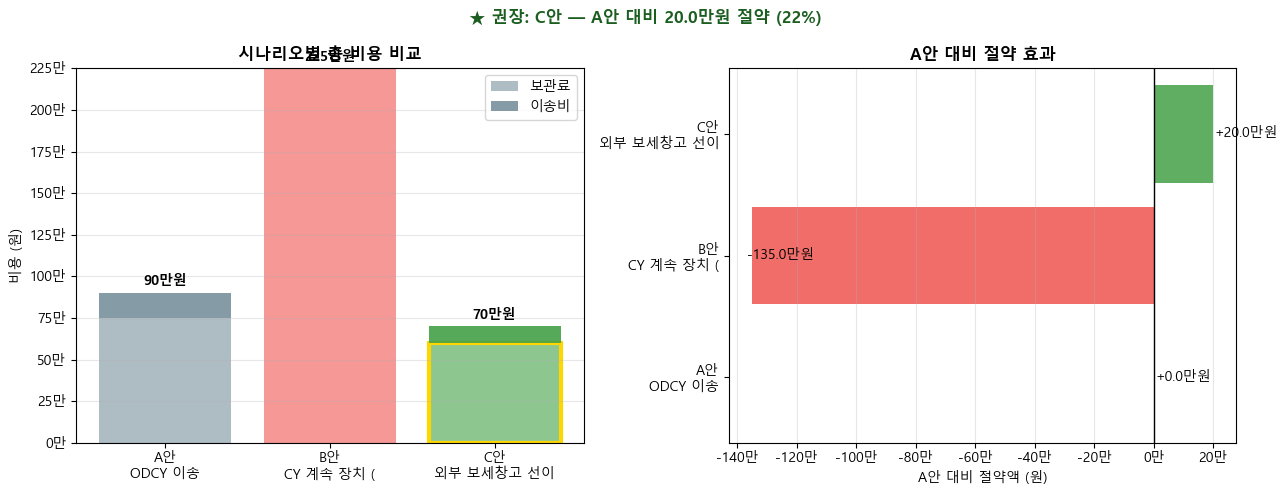

In [12]:
# 시나리오 A/B/C 비용 비교 차트
from src.scenario_cost import calc_scenarios, print_scenario_table
import matplotlib.pyplot as plt
import numpy as np

scenarios = calc_scenarios(cbm=cbm, delay_days=EXPECTED_DELAY_DAYS)
print_scenario_table(scenarios, title=f'시나리오 비용 비교 (CBM={cbm}, 지연={EXPECTED_DELAY_DAYS}일)')

# 차트
labels     = [s.label + '안\n' + s.name.split(' — ')[-1][:10] for s in scenarios]
storage    = [s.storage_krw  for s in scenarios]
transfer   = [s.transfer_krw for s in scenarios]
totals     = [s.total_krw    for s in scenarios]
bar_colors = ['#78909C', '#EF5350', '#43A047']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 막대 (누적)
x = np.arange(len(scenarios))
b1 = ax1.bar(x, storage,  color=[c + '99' for c in ['#78909C','#EF5350','#43A047']],
             label='보관료')
b2 = ax1.bar(x, transfer, bottom=storage,
             color=['#78909C','#EF5350','#43A047'], label='이송비', alpha=0.9)

for i, (tot, lab) in enumerate(zip(totals, labels)):
    ax1.text(i, tot + max(totals)*0.02, f'{tot/10000:.0f}만원',
             ha='center', fontweight='bold', fontsize=10)

rec_idx = next((i for i, s in enumerate(scenarios) if s.recommend), 2)
ax1.get_children()[rec_idx].set_edgecolor('gold')
ax1.get_children()[rec_idx].set_linewidth(3)

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('비용 (원)')
ax1.set_title('시나리오별 총 비용 비교', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))

# A 대비 절약 효과
a_total = scenarios[0].total_krw
savings = [(a_total - s.total_krw) for s in scenarios]
s_colors = ['gray'] + ['#EF5350' if sv < 0 else '#43A047' for sv in savings[1:]]
ax2.barh(labels, savings, color=s_colors, alpha=0.85)
ax2.axvline(0, color='black', linewidth=1)
for i, sv in enumerate(savings):
    ax2.text(sv + (max(savings)*0.02 if sv >= 0 else -max(savings)*0.08),
             i, f'{sv/10000:+.1f}만원', va='center', fontsize=10)
ax2.set_xlabel('A안 대비 절약액 (원)')
ax2.set_title('A안 대비 절약 효과', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))

rec = next((s for s in scenarios if s.recommend), scenarios[-1])
fig.suptitle(f'★ 권장: {rec.label}안 — A안 대비 {(a_total-rec.total_krw)/10000:.1f}만원 절약'
             f' ({(a_total-rec.total_krw)/a_total*100:.0f}%)',
             fontsize=12, fontweight='bold', color='#1B5E20')
plt.tight_layout()
plt.show()


In [13]:
# 창고 위치 지도 시각화 (folium 있으면 인터랙티브, 없으면 matplotlib)
try:
    import folium
    m = folium.Map(location=[dest_lat, dest_lng], zoom_start=12)
    folium.Marker([dest_lat, dest_lng],
        popup=f'📍 {port_name} CY',
        icon=folium.Icon(color='blue', icon='ship', prefix='fa')
    ).add_to(m)
    colors_f = ['red','orange','green','purple','darkblue']
    for i, wh in enumerate(warehouses):
        wh_lat = float(wh.get('lat') or dest_lat)
        wh_lng = float(wh.get('lng') or dest_lng)
        folium.Marker(
            [wh_lat, wh_lng],
            popup=f'{i+1}위: {wh["name"]}\n{wh["distance_km"]:.1f}km',
            icon=folium.Icon(color=colors_f[i], icon='warehouse', prefix='fa')
        ).add_to(m)
    display(m)
except ImportError:
    print('folium 미설치 — pip install folium으로 인터랙티브 지도 활성화')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(dest_lng, dest_lat, s=200, c='blue', zorder=5, label=f'{port_name} CY')
    for i, wh in enumerate(warehouses):
        wh_lat = float(wh.get('lat') or dest_lat + 0.01*(i+1))
        wh_lng = float(wh.get('lng') or dest_lng + 0.01*(i+1))
        ax.scatter(wh_lng, wh_lat, s=100, zorder=4)
        ax.annotate(f'{i+1}.{wh["name"][:8]}', (wh_lng, wh_lat), fontsize=8)
    ax.set_title('창고 위치 (개략도)')
    ax.legend()
    plt.tight_layout()
    plt.show()


---
# Part 4 — 루티(ROOUTY) 연계 JSON 출력

시나리오 C(외부 창고 사전 이송)를 선택했을 때,  
루티(ROOUTY) 플랫폼에 **화물 운송 지시서(JSON)**를 자동 생성합니다.

## 운송 단계

```
출발지(화주 공장/창고)  →  추천 보세창고  →  (선적 재개 시 화주 직접 CY 반입)
         ↑
    Phase 1 JSON (이 파일이 생성)
```

> Phase 2(창고→CY)는 화주가 선적 재개 시점을 직접 결정하므로 JSON에서 제외합니다.
> 선적 재개 확정 후 별도 운송 지시 필요.


In [14]:
# Phase 1 루티 JSON 생성 (출발지 → 보세창고)
from src.storage_routy_adapter import generate_storage_routy_json, save_storage_json
from src.mri_engine import mri_grade
import json

# 추천 창고 1순위 선택
selected_wh = warehouses[0] if warehouses else {
    'name': '부산항 인근 보세창고', 'address': '부산광역시 동구',
    'phone': '051-000-0000', 'type': '보세창고',
    'distance_km': 5.0, 'duration_min': 15.0, 'special_notes': ''
}

mri_val = float(mri_history_df.iloc[-1]['mri_entropy'])
grade_str, _ = mri_grade(mri_val)

routy_json = generate_storage_routy_json(
    shipment_id       = f"SH-{SHIPPER_INPUT['company'][:3].upper()}-001",
    company           = SHIPPER_INPUT['company'],
    region            = SHIPPER_INPUT['region'],
    cargo_type        = SHIPPER_INPUT['cargo_type'],
    cbm               = SHIPPER_INPUT['cbm'],
    cold_chain        = SHIPPER_INPUT['cargo_type'] in ('냉장화물', '냉동화물'),
    hazmat            = SHIPPER_INPUT['cargo_type'] in ('위험물', '2차전지'),
    origin_address    = SHIPPER_INPUT['origin_address'],
    original_port     = SHIPPER_INPUT['origin_port'],
    original_pickup_date = SHIPPER_INPUT['pickup_date'],
    mri_current       = mri_val,
    delay_reason      = f'MRI {mri_val:.3f} [{grade_str}] — 해상 리스크 탐지',
    recommended_warehouse = selected_wh,
)

print('=== 루티 Phase 1 JSON ===')
print(json.dumps(routy_json, ensure_ascii=False, indent=2, default=str))

# JSON 저장
try:
    saved = save_storage_json(routy_json, PROJECT_ROOT / 'output')
    print(f'\nJSON 저장: {saved}')
except Exception as e:
    print(f'\n저장 오류: {e}')


=== 루티 Phase 1 JSON ===
{
  "execution_group_id": "EG-20260515-STORAGE-SH-(주)-001",
  "generated_at": "2026-05-15T22:02:06",
  "phase": "PHASE1_TO_STORAGE",
  "phase_description": "해상 리스크 발생 → 출발지에서 항만 인근 창고·ODCY로 임시 운송",
  "risk_context": {
    "mri_current": 0.191,
    "delay_reason": "MRI 0.191 [🟢 정상] — 해상 리스크 탐지",
    "original_port": "부산항(북항)",
    "original_pickup": "2026-06-10",
    "decision": "HOLDBACK_TO_STORAGE"
  },
  "shipment": {
    "shipment_id": "SH-(주)-001",
    "company": "(주)한국무역",
    "region": "경기남부",
    "cargo_type": "일반화물",
    "cbm": 15.0,
    "cold_chain": false,
    "hazmat": false,
    "origin_address": "경기도 화성시 마도면"
  },
  "dispatch": {
    "origin": {
      "name": "(주)한국무역 출고지",
      "address": "경기도 화성시 마도면"
    },
    "destination": {
      "name": "디앤케이물류㈜",
      "address": "부산광역시 중구 대교로 141",
      "phone": "",
      "type": "물류창고(NLIC)",
      "lat": null,
      "lng": null
    },
    "adjusted_pickup": "2026-06-09",
    "action": "DELIVER_TO_STORA

---
# 📋 데이터 유지보수 가이드 (개발자용)

플랫폼이 최신 데이터를 반영하려면 아래 항목을 주기적으로 업데이트해야 합니다.  
**노트북을 실행하기 전 아래 체크리스트를 확인하세요.**

---

## ⏰ 주간 업데이트 (매주 월요일 권장)

| 데이터 | 수집처 | 저장 경로 | 방법 |
|--------|--------|----------|------|
| **SCFI** (상해컨테이너운임지수) | [en.sse.net.cn](https://en.sse.net.cn/indices/scfinew.jsp) | `SCFI,CCFI 2015.01 ~ 2026.05/` | 주간 Excel 다운로드 → 기존 파일에 행 추가 |
| **CCFI** (중국컨테이너운임지수) | [chineseshipping.com.cn](http://en.chineseshipping.com.cn) | 동일 폴더 | SCFI와 동일 파일 내 CCFI 탭 |
| **KCCI** (한국컨테이너운임지수) | [KSIS ksis.go.kr](https://www.ksis.go.kr) | `data/freight_index/` | KSIS 포털 → 운임지수 → KCCI 다운로드 |

---

## 📅 월간 업데이트 (매월 초, BPA 발표 후)

| 데이터 | 수집처 | 저장 경로 | 방법 |
|--------|--------|----------|------|
| **BPA 부산항 물동량** | [busanpa.com](https://www.busanpa.com) | `15년~26년/YYYY년/` 연도별 폴더 | BPA 통계 → 월별물동량 XLS → 해당 연도 폴더에 저장 ※ 보통 2~3개월 후 공개 |
| **GDELT BigQuery CSV** | Google BigQuery (`gdelt-bq.gdeltv2.events`) | `data/gdelt_maritime_monthly.csv` | 아래 SQL 재실행 → CSV 내보내기 → 덮어쓰기 |

---

## 🤖 자동 수집 (코드가 실행 시 자동 처리)

| 데이터 | 방법 | 비고 |
|--------|------|------|
| 해사 뉴스 (RSS) | gCaptain / Splash247 / 한국해운신문 RSS | 실행 시 실시간 수집 |
| Naver DataLab | 네이버 오픈API | `NAVER_CLIENT_ID` 환경변수 필요 |
| 환율 (USD/KRW) | ECOS API → frankfurter.app 폴백 | `ECOS_API_KEY` 또는 무키 |
| 유가 (Brent) | Yahoo Finance BZ=F → FRED | 인터넷 연결 필요 |
| BPA LSTM 공백 보완 | 2-layer LSTM 자동 예측 (최대 3개월) | 최신 BPA 업로드 후 자동 해소 |

---

## 🔑 환경변수(.env) 키 목록

```
NAVER_CLIENT_ID=...         # Naver DataLab (developers.naver.com)
NAVER_CLIENT_SECRET=...     # Naver DataLab
KAKAO_REST_API_KEY=...      # 카카오 Local 창고 검색
KAKAO_MOBILITY_KEY=...      # 카카오모빌리티 경로 계산
BPA_API_KEY=...             # 부산항 물동량 API (선택)
ECOS_API_KEY=...            # 한국은행 환율
GEMINI_API_KEY=...          # LLM 보고서 (선택)
```

---

## 🗄️ GDELT BigQuery SQL (월간 업데이트용)

BigQuery 콘솔에서 실행 후 결과를 `data/gdelt_maritime_monthly.csv`로 저장:

```sql
SELECT
  FORMAT_TIMESTAMP('%Y-%m', TIMESTAMP(CAST(SQLDATE AS STRING), 'UTC')) AS ym,
  COUNTIF(EventRootCode IN ('19','18','17','16','15','14','13','12','11'))
    AS G_conflict_count,
  COUNTIF(Actor1CountryCode IN ('YEM','IRN','RUS','UKR')
       OR Actor2CountryCode IN ('YEM','IRN','RUS','UKR'))
    AS G_hotspot_count,
  COUNTIF(EventCode IN ('1211','1221','1231','1241'))
    AS P_sanction_count,
  COUNTIF(AvgTone < -3)
    AS D_negative_count,
  AVG(AvgTone)        AS avg_tone,
  AVG(GoldsteinScale) AS avg_goldstein,
  COUNT(DISTINCT GLOBALEVENTID) AS total_articles,
  COUNT(*)            AS total_events
FROM `gdelt-bq.gdeltv2.events`
WHERE
  (Actor1CountryCode IN ('KOR','CHN','JPN','USA','SGP','MYS','THA','TWN','YEM','IRN','RUS','UKR')
   OR Actor2CountryCode IN ('KOR','CHN','JPN','USA','SGP','MYS','THA','TWN','YEM','IRN','RUS','UKR'))
  AND SQLDATE BETWEEN 20150201 AND 20261231
GROUP BY ym
ORDER BY ym
```

---

## 📁 파일 경로 구조

```
vs code/  (프로젝트 루트)
├── SCFI,CCFI 2015.01 ~ 2026.05/   ← 주간 업데이트 (SCFI/CCFI Excel)
├── 15년~/26년/                      ← 월간 업데이트 (BPA 물동량 XLS)
├── data/
│   ├── freight_index/              ← 주간 업데이트 (KCCI XLS)
│   ├── gdelt_maritime_monthly.csv  ← 월간 업데이트 (BigQuery 결과)
│   └── nlic_warehouses.json        ← 연간 업데이트 (창고 DB)
├── src/                            ← 소스 코드 (변경 불필요)
├── notebooks/
│   └── wemeet_v4_main.ipynb        ← 발표용 메인 노트북
├── output/                         ← 생성된 JSON, 차트
└── .env                            ← API 키 (git에 올리지 말 것)
```

> ⚠️ **주의**: `.env` 파일은 절대 GitHub/공개 저장소에 업로드하지 마세요.
